In [108]:
import matplotlib.pyplot
import pandas
from pathlib import Path

In [147]:
def parse_summary_log(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'core', 'event', 'value', 'enabled', 'running']
    data_frame = pandas.read_csv(file_path, header=None, names=columns)
    data_frame['timestamp_ns'] = pandas.to_datetime(data_frame['timestamp_ns'], unit='ns')
    return data_frame.set_index('timestamp_ns').sort_index().fillna(1.0)

def plot_event(file_path : str, event : str) -> None:
    data_frame = parse_summary_log(file_path)
    data_frame = data_frame[data_frame['event'] == event]
    data_frame = data_frame[data_frame['core'] == 1]
    data_frame = (data_frame['value'] * data_frame['running'] / data_frame['enabled']).diff()

    print(data_frame.to_string())

    matplotlib.pyplot.figure(figsize=(20, 16))
    matplotlib.pyplot.plot(data_frame)

timestamp_ns
1970-01-01 02:46:46.284799900        NaN
1970-01-01 02:46:46.308401505        0.0
1970-01-01 02:46:46.332752716        0.0
1970-01-01 02:46:46.355416812        0.0
1970-01-01 02:46:46.377940368        0.0
1970-01-01 02:46:46.400712103        0.0
1970-01-01 02:46:46.423333947        0.0
1970-01-01 02:46:46.445807394        0.0
1970-01-01 02:46:46.468328008        0.0
1970-01-01 02:46:46.491547095        0.0
1970-01-01 02:46:46.513559922        0.0
1970-01-01 02:46:46.536083485        0.0
1970-01-01 02:46:46.557801810        0.0
1970-01-01 02:46:46.580547431        0.0
1970-01-01 02:46:46.603552293        0.0
1970-01-01 02:46:46.626106846        0.0
1970-01-01 02:46:46.648798158        0.0
1970-01-01 02:46:46.670561887        0.0
1970-01-01 02:46:46.693265580        0.0
1970-01-01 02:46:46.715545367        0.0
1970-01-01 02:46:46.738233119        0.0
1970-01-01 02:46:46.760552842        0.0
1970-01-01 02:46:46.782561880        0.0
1970-01-01 02:46:46.805397520        0.0
197

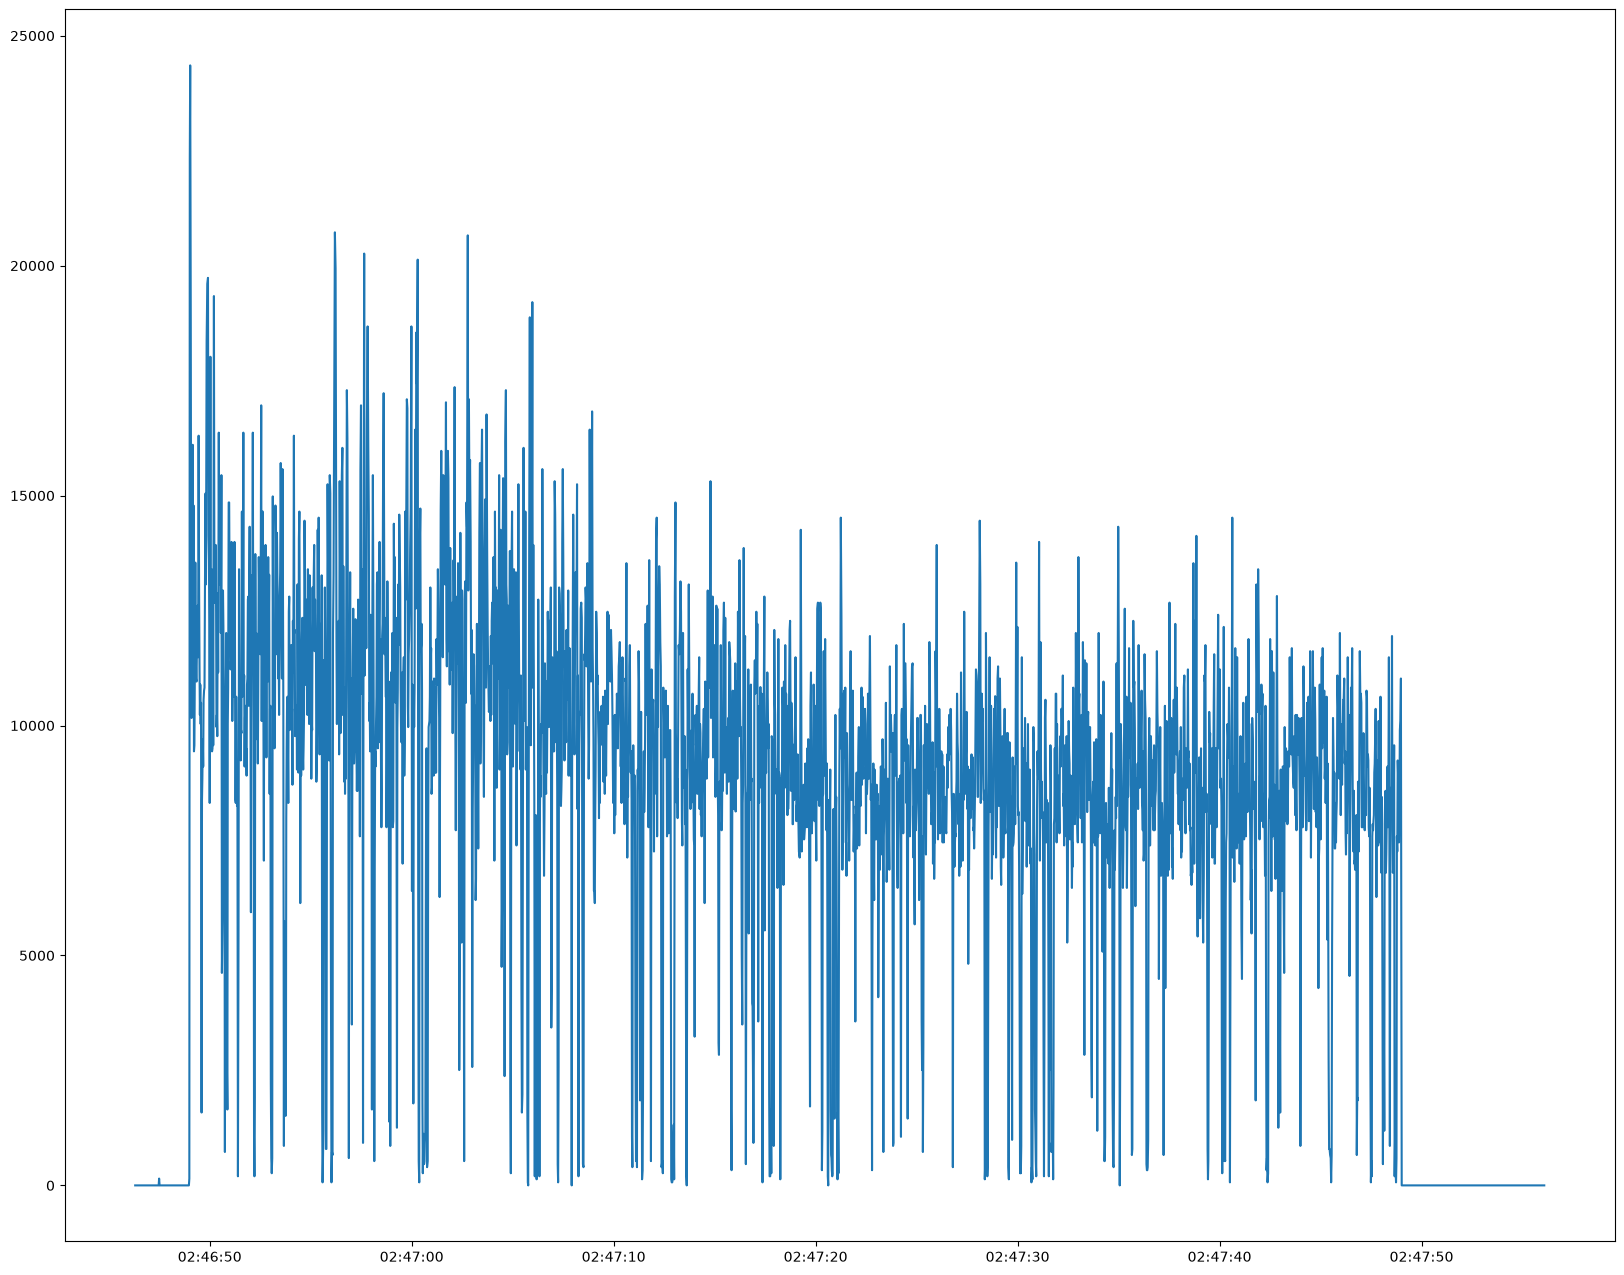

In [148]:
plot_event("results/summary.log", 'tx_bytes')